# Learning Curves

A learning curve is a graph that shows how a machine learning model performs as the amount of training data increases.

It helps us understand how well a model is learning and whether it improves with more data.

## What It Plots

A learning curve compares:

- **Training Score**
- **Validation Score**

against:

- **Number of Training Samples**

## Why Learning Curves are Useful

- Detect overfitting or underfitting  
- Understand model behavior with more data  
- Decide if adding more data will help  
- Help improve model selection and tuning  

## Key Patterns

### 1. Overfitting (High Variance)

- Training score → very high  
- Validation score → low  
- Large gap between both  

**Meaning:**
- Model learns training data too well  
- Performs poorly on new/unseen data  

### 2. Underfitting (High Bias)

- Training score → low  
- Validation score → low  
- Both scores are close  

**Meaning:**
- Model is too simple  
- Cannot capture patterns in data  

### 3. Good Fit

- Training score → high  
- Validation score → slightly lower  
- Small gap between both  

**Meaning:**
- Model generalizes well  
- Performs well on both training and unseen data  

> Learning curves help you visually understand whether your model is learning properly and guide you to improve performance by adjusting model complexity or adding more data.

---

## 1. Overfitting

### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler

### Load dataset
***Here, the breast cancer dataset from scikit-learn is used***

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

### Standardize data 

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Train model  

In [4]:
model = DecisionTreeClassifier(max_depth=None) 

### Generate learning curve

In [5]:
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

### Calculate mean scores

In [6]:
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

### Plot learning curve

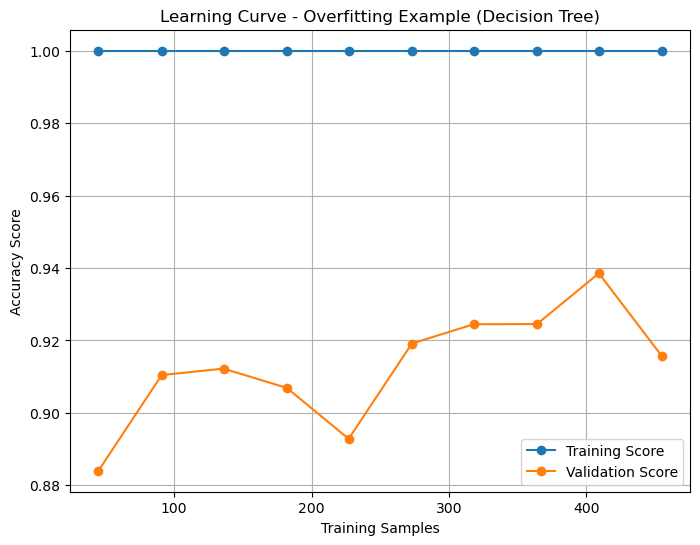

In [7]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score", marker='o')
plt.plot(train_sizes, val_mean, label="Validation Score", marker='o')

plt.title("Learning Curve - Overfitting Example (Decision Tree)")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()

---

## 2. Underfitting

### Import libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

### Load dataset
***Here, the digits dataset from scikit-learn is used***

In [9]:
data = load_digits()
X = data.data
y = data.target

### Standardize data

In [10]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Train model 

In [11]:
model = GaussianNB()

### Generate learning curve

In [12]:
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

### Compute mean scores

In [13]:
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

### Plot learning curve

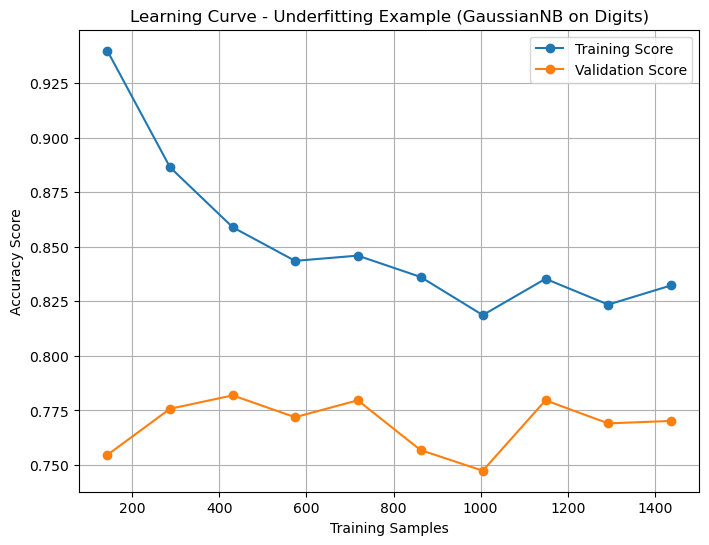

In [14]:
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")
plt.title("Learning Curve - Underfitting Example (GaussianNB on Digits)")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()

---

## 3. Good Fit

### Import libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### Load dataset
***Here, the breast cancer dataset from scikit-learn is used***

In [16]:
data = load_breast_cancer()
X = data.data
y = data.target

### Standardize data

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Train model

In [18]:
model = LogisticRegression(
    C=0.01,        
    max_iter=100   
)

### Generate learning curve

In [19]:
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

### Compute mean scores

In [20]:
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

### Plot learning curve

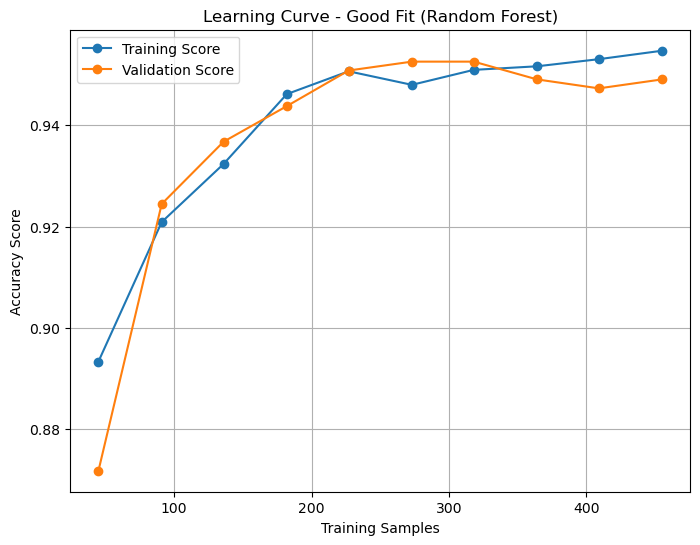

In [21]:
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, val_mean, marker='o', label="Validation Score")
plt.title("Learning Curve - Good Fit (Random Forest)")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy Score")
plt.legend()
plt.grid()
plt.show()